##### Implementing: [Playlist](https://www.youtube.com/playlist?list=PLa14hsXP1CHRya4B4sK234p9YBB-Tgbqm)

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time

### Loading and making the datset compatible with everything

In [2]:
dataset_train = pd.read_csv('leaf-classification/train.csv')
dataset_test = pd.read_csv('leaf-classification/test.csv')

dataset_train.shape, dataset_test.shape

((990, 194), (594, 193))

In [3]:
dataset_train.sample(5)

,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
766,1231,Quercus_Pontica,0.001953,0.003906,0.046875,0.003906,0.017578,0.005859,0.027344,0.0,...,0.006836,0.0,0.032227,0.000000,0.020508,0.00000,0.0,0.000000,0.004883,0.001953
501,810,Acer_Pictum,0.001953,0.001953,0.027344,0.070312,0.003906,0.000000,0.000000,0.0,...,0.171880,0.0,0.008789,0.000000,0.016602,0.00000,0.0,0.000000,0.000000,0.016602
62,106,Ilex_Cornuta,0.078125,0.066406,0.019531,0.007812,0.000000,0.130860,0.021484,0.0,...,0.282230,0.0,0.008789,0.000977,0.000000,0.00000,0.0,0.000000,0.000000,0.016602
329,542,Prunus_X_Shmittii,0.000000,0.000000,0.007812,0.003906,0.027344,0.000000,0.017578,0.0,...,0.000000,0.0,0.004883,0.003906,0.040039,0.00000,0.0,0.000000,0.017578,0.060547
198,339,Betula_Pendula,0.000000,0.000000,0.031250,0.011719,0.021484,0.000000,0.001953,0.0,...,0.000000,0.0,0.000000,0.025391,0.000000,0.41602,0.0,0.058594,0.003906,0.000000


In [4]:
X = dataset_train.drop(columns=['id', 'species']).values
y = dataset_train['species'].values
X_test = dataset_test.drop(columns=['id']).values
X.shape, y.shape, X_test.shape

((990, 192), (990,), (594, 192))

In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_valid, y_train, y_valid = train_test_split(X, y_encoded, test_size=0.2, random_state=123)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((792, 192), (792,), (198, 192), (198,))

### Borrowing from Simple Decision Tree, but vectorizing it

In [6]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):
        # A Node can either be a Decision Node or a Pure Node
        
        # Decision Node: Splitting data based on a feature with some threshold
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right

        # Leaf Node: Pure, hence only has which class it belongs to
        self.value = value

In [7]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=2):
        # Min Samples for splitting to occur
        self.min_samples_split=min_samples_split
        # Max depth for base case and preventing overfitting
        self.max_depth = max_depth

    def build_tree(self, X, y, curr_depth=0):
        n_samples, n_features = X.shape

        # For a Decision Node
        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.best_split(X, y, n_features)

            # Ensuring not a pure node, and no feature exhaustion
            if best_split["info_gain"] > 0:
                left_node = self.build_tree(best_split["left_X"], best_split["left_y"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_X"], best_split["right_y"], curr_depth + 1)

                return Node(best_split["feature_idx"], best_split["threshold"], best_split["info_gain"], left_node, right_node)

        # Returning a Pure Node with Majority class
        classes, counts = np.unique(y, return_counts=True)
        leaf_value = classes[np.argmax(counts)]
        return Node(value=leaf_value)

    def best_split(self, X, y, n_feature):
        b_split = {
            "feature_idx": None,
            "threshold": None,
            "info_gain": -1,
            "left_X": None,
            "left_y": None,
            "right_X": None,
            "right_y": None
        }

        # This remains same in the loop, hence shouldn't calc it again and again
        y_entropy = self.entropy(y)

        # Trying every possible feature x with every possible threshold to break and find resulting purity
        for feature_idx in range(n_feature):
            feature_values = X[:, feature_idx]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_X, left_y, right_X, right_y = self.split(X, y, feature_idx, threshold) 

                if len(left_y) and len(right_y):
                    info_gain = self.information_gain(y_entropy, len(y), left_y, right_y)

                    if info_gain > b_split["info_gain"]:
                        b_split["feature_idx"] = feature_idx
                        b_split["threshold"] = threshold
                        b_split["info_gain"] = info_gain
                        b_split["left_X"] = left_X
                        b_split["left_y"] = left_y
                        b_split["right_X"] = right_X
                        b_split["right_y"] = right_y

        return b_split

    def split(self, X, y, feature_idx, threshold):
        # Need to find the mask only once for efficiency
        mask = X[:, feature_idx] <=threshold
        
        left_X = X[mask]
        left_y = y[mask]
        right_X = X[~mask]
        right_y = y[~mask]
        return left_X, left_y, right_X, right_y

    def information_gain(self, y_entropy, y_len, left_y, right_y):
        left_weight = len(left_y) / y_len
        right_weight = len(right_y) / y_len
        information_gain = y_entropy - (self.entropy(left_y) * left_weight) - (self.entropy(right_y) * right_weight)
        return information_gain

    def gini_impurity(self, y):
        class_labels, counts = np.unique(y, return_counts = True)
        probabilities = counts / len(y)
        return np.sum(-np.square(probabilites)) + 1

    # Got 54s -> 26s just by vectorizing the impurities
    def entropy(self, y):
        class_labels, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log(probabilities))

    def predict(self, X):
        predictions = [self.predict_class(row, self.root) for row in X]
        return predictions

    def predict_class(self, x, node):
        # Leaf Node: Base case
        if node.value is not None:
            return node.value
        # Decision Node
        feature_value = x[node.feature_idx] 
        if feature_value <= node.threshold:
            return self.predict_class(x, node.left)
        else:
            return self.predict_class(x, node.right)

    def fit(self, X, y):
        self.root = self.build_tree(X, y)


In [23]:
start = time.time()
start = time.time()
dt_fast = DecisionTree(max_depth=1)
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(0.0), 4.666558027267456)

In [11]:
start = time.time()
start = time.time()
dt_fast = DecisionTree(max_depth=float('inf'))
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(62.121212121212125), 19.123809099197388)

### Our simple DecisionTree with different premitted depths

In [12]:
models = []
accuracies = []
training_times = []

for depth in range(3, 15, 2):
    start = time.time()
    dt = DecisionTree(max_depth = depth)
    dt.fit(X_train, y_train)
    end = time.time()
    predictions = dt.predict(X_valid)
    
    accuracy = np.mean(predictions == y_valid) * 100

    print(f"Model with {depth=} preforming with {accuracy=}%, trained in time: {end - start}s")

    models.append(dt)
    accuracies.append(accuracy)
    training_times.append(end - start)

f"Last Model {accuracy=} at {depth=}"

Model with depth=3 preforming with accuracy=np.float64(2.525252525252525), trained in time: 9.847636938095093s
Model with depth=5 preforming with accuracy=np.float64(18.181818181818183), trained in time: 13.230884075164795s
Model with depth=7 preforming with accuracy=np.float64(55.05050505050505), trained in time: 16.496129035949707s
Model with depth=9 preforming with accuracy=np.float64(62.121212121212125), trained in time: 18.994128227233887s
Model with depth=11 preforming with accuracy=np.float64(62.121212121212125), trained in time: 18.961466073989868s
Model with depth=13 preforming with accuracy=np.float64(62.121212121212125), trained in time: 19.104626178741455s


'Last Model accuracy=np.float64(62.121212121212125) at depth=13'

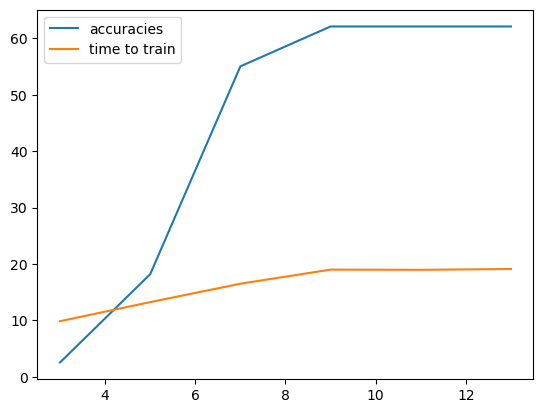

In [13]:
from matplotlib import pyplot as plt

depths = np.arange(3, 15, 2)
plt.plot(depths, accuracies, label='accuracies')
plt.plot(depths, training_times, label='time to train')
plt.legend()
plt.show()

### Skelearn DecisionTreeClassifier

In [14]:
from sklearn.tree import DecisionTreeClassifier

start = time.time()
dt_fast = DecisionTreeClassifier(max_depth=None, random_state=123)
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(62.62626262626263), 0.2360529899597168)

### Sklearn RandomForestClassifer

In [15]:
from sklearn.ensemble import RandomForestClassifier

start = time.time()
dt_fast = RandomForestClassifier(n_estimators=1000, random_state=123)
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(98.48484848484848), 8.547035217285156)

### Doing the same using XGBoost

In [21]:
from xgboost import XGBClassifier

start = time.time()
xgb = XGBClassifier(max_depth=9, random_state=123).fit(X_train, y_train)
end = time.time()
xgb_predictions = xgb.predict(X_valid)
accuracy = np.mean(xgb_predictions==y_valid)*100
accuracy, end - start

(np.float64(87.37373737373737), 2.7738423347473145)

### Implementing Random Forest for Better performance

In [17]:
class RandomForest:
    def __init__(self, num_trees=10, max_depth=4, min_samples_split=2):
         self.trees = []
         self.num_trees = num_trees
         self.max_depth = max_depth
         self.min_samples_split = min_samples_split

    def fit(self, X, y):
        n_rows, n_features = X.shape

        for i in range(self.num_trees):
            dt = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)

            # Choose a random subset with replacement
            idxs = np.random.choice(n_rows, n_rows, replace=True)
    
            # Choosing a random set of features to train on
            features = np.random.choice(n_features, int(0.7*n_features), replace=False)

            # Training and adding this model to our arsenal
            X_sample, y_sample = X[idxs][:, features], y[idxs]
            dt.fit(X_sample, y_sample)
            self.trees.append((dt, features))

            print(f"{i} th iteration is done")

    def predict(self, X):

        all_predictions = np.array([dt.predict(X[:, features]) for dt, features in self.trees])

        all_predictions = all_predictions.T

        final_predictions = []

        for row in all_predictions:
            classes, counts = np.unique(row, return_counts=True)
            final_predictions.append(classes[np.argmax(counts)])

        return np.array(final_predictions)
        

In [18]:
start = time.time()
rf = RandomForest(num_trees=10, max_depth=float('inf'))
rf.fit(X_train, y_train)
end = time.time()
end - start

0 th iteration is done
1 th iteration is done
2 th iteration is done
3 th iteration is done
4 th iteration is done
5 th iteration is done
6 th iteration is done
7 th iteration is done
8 th iteration is done
9 th iteration is done


84.1228129863739

In [19]:
np.mean(rf.predict(X_valid) == y_valid)*100

np.float64(85.35353535353535)

### Final Result

|Model| Accuracy(\%) | Time to Train(s)
|--|--|--|
| Simple Scratch Decision Tree | 62.12 | 25
| sklearn DecisionTreeClassifier | 62.62 | 0.26
| xgboost XGBClassifier | 87.38 | 2.81
| sklearn RandomForestClassifier | 97.4747 | 0.81 
| Simple Scratch Random Forest  | 85.859 | 224